# Breast_Cancer_Prediction_using_RandomForest_with_PCA

**Note:**
- In this experiment, we will perform several operations on a CSV file using the NumPy, Pandas, Matplotlib, Seaborn, and SKLearn libraries.
- Our primary focus will be on key operations commonly used in these libraries for building Linear Regression models.
- The following operations will be conducted on the CSV file:

   - Importing the necessary libraries.
   - Loading the dataset for the experiment.
   - Understanding the data contained in the file.
   - Performing data cleaning and visualization operations.
   - Preparing the data for further processing within the Data Science Life Cycle.
   - Conducting Exploratory Data Analysis (EDA) on the processed data.
   - Building predictive models using the EDA-processed data.
   - Performing model evaluations.

**Experiment Link** --> https://colab.research.google.com/drive/1QARk7ER4nCcKDJX3a2UXobox0WUc6lyH?usp=sharing


### STEP 1. Problem statement:-
   - We want to perform the predictions on breast cancer patients for who were wants the diganosis based on there reports result values.

### STEP 2.Importing the necessary libraries.


In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### STEP 3.Loading the Dataset into the Environment.


In [2]:
# Loading the dataset.
from sklearn.datasets import load_breast_cancer

In [3]:
#  we want to make the data into a DataFrame
data = load_breast_cancer()
x = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

In [4]:
# Understanding the dataset.
df = pd.DataFrame(x, columns=feature_names)
df['Diagnosis'] = y
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
# Displaying all columns' data.
pd.set_option('display.max_columns', None)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [7]:
df.shape

(569, 31)

In [8]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,Diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [9]:
df['Diagnosis'].value_counts()

,count
Diagnosis,
1,357
0,212


- Observing the data set for how many types of data are contained in the CSV_file.
- By this, we understand the dataset's composition and the different data types present in the file.


### STEP 4.Data Cleaning Operation performed om the dataset.


In [10]:
# checking for null values.
df.isnull().sum()

,0
mean radius,0
mean texture,0
mean perimeter,0
mean area,0
mean smoothness,0
mean compactness,0
mean concavity,0
mean concave points,0
mean symmetry,0
mean fractal dimension,0


In [11]:
#Check for duplicates
df.duplicated().sum()

np.int64(0)

### STEP 5.Exploratory Data Analysis(EDA)

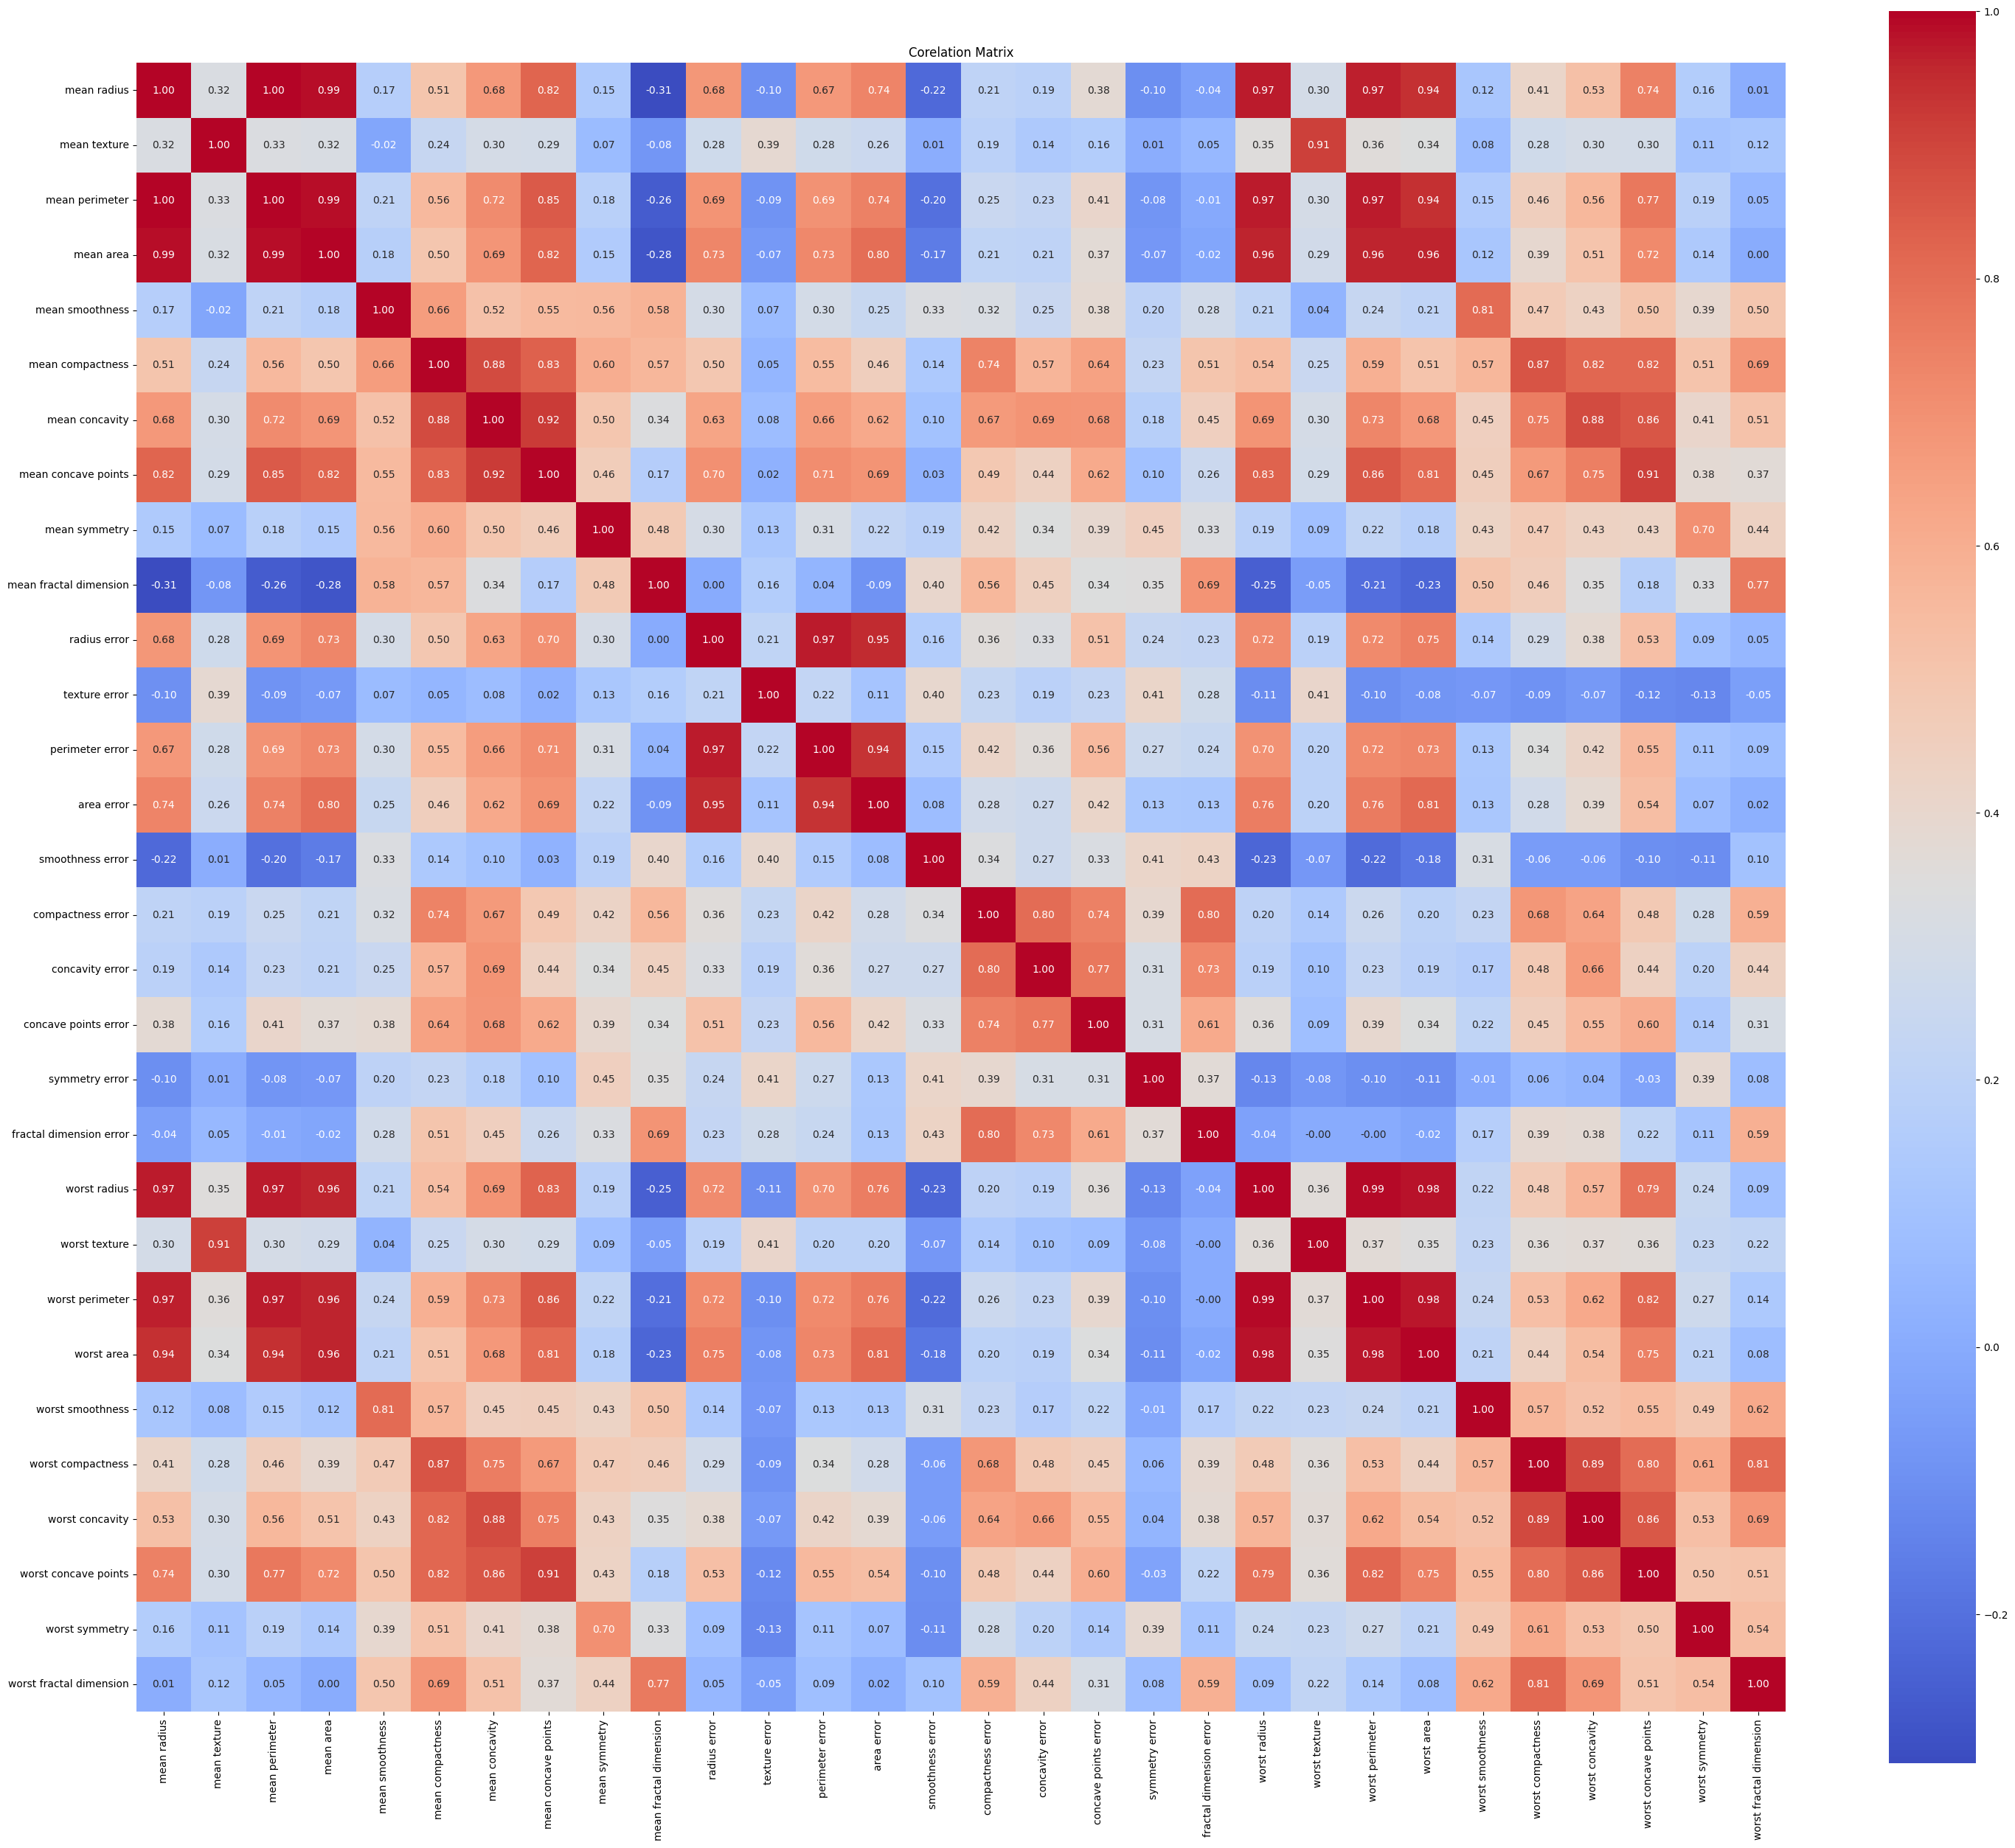

In [12]:
#Check for the correlation b/w all columns
plt.figure(figsize=(30,30))
correlation_matrix = df.iloc[:,:30].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f",cmap='coolwarm',
            square=True,cbar_kws = {'shrink':0.8})
plt.tight_layout()
plt.title("Corelation Matrix")
plt.show()

In [13]:
# Extracing highly correlational pairs
print("Highly corelated factors (>0.90):\n")
for i in range(len(correlation_matrix.columns)):
  for j in range(i+1, len(correlation_matrix.columns)):
    if abs(correlation_matrix.iloc[i,j]) > 0.90:
      print(f"{correlation_matrix.columns[i]} & {correlation_matrix.columns[j]} : {correlation_matrix.iloc[i,j]:.2f}")

Highly corelated factors (>0.90):

mean radius & mean perimeter : 1.00
mean radius & mean area : 0.99
mean radius & worst radius : 0.97
mean radius & worst perimeter : 0.97
mean radius & worst area : 0.94
mean texture & worst texture : 0.91
mean perimeter & mean area : 0.99
mean perimeter & worst radius : 0.97
mean perimeter & worst perimeter : 0.97
mean perimeter & worst area : 0.94
mean area & worst radius : 0.96
mean area & worst perimeter : 0.96
mean area & worst area : 0.96
mean concavity & mean concave points : 0.92
mean concave points & worst concave points : 0.91
radius error & perimeter error : 0.97
radius error & area error : 0.95
perimeter error & area error : 0.94
worst radius & worst perimeter : 0.99
worst radius & worst area : 0.98
worst perimeter & worst area : 0.98


- We have almost 21 highly correlated columns in the data.

### STEP 6.Feature Engineering for Encoding,Scaling,Feature creation.


In [14]:
from sklearn.preprocessing import StandardScaler

In [16]:
# Applying standardscaler on the x_features data.
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

print("Before Standardization")
print(f"Mean of first feature: {x[:,0].mean()}")
print(f"Std of first feature: {x[:,0].std()}")
print("=="*40)
print("After Standardization")
print(f"Mean of first feature: {x_scaled[:,0].mean()}")
print(f"Std of first feature: {x_scaled[:,0].std()}")

Before Standardization
Mean of first feature: 14.127291739894552
Std of first feature: 3.520950760711062
After Standardization
Mean of first feature: -3.153111437248248e-15
Std of first feature: 0.9999999999999998


-  Now, all x_features columns within the data have been converted into a standard scale format.


In [17]:
# STEP 2- COMPUTE COVARIANCE MATRIX-
# inorder to find out the relation b/w features -
x1 = x_scaled.T
pd.DataFrame(x1)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495,496,497,498,499,500,501,502,503,504,505,506,507,508,509,510,511,512,513,514,515,516,517,518,519,520,521,522,523,524,525,526,527,528,529,530,531,532,533,534,535,536,537,538,539,540,541,542,543,544,545,546,547,548,549,550,551,552,553,554,555,556,557,558,559,560,561,562,563,564,565,566,567,568
0,1.097064,1.829821,1.579888,-0.768909,1.750297,-0.476375,1.170908,-0.118517,-0.320167,-0.473535,0.537556,0.469393,1.432201,0.489274,-0.112836,0.117215,0.156977,0.568798,1.613970,-0.166799,-0.297446,-1.313080,0.344426,1.997389,0.716485,0.855652,0.128576,1.273153,0.333066,0.977778,1.278833,-0.649623,0.821570,1.460602,0.568798,0.742046,0.034851,-0.311646,0.245021,-0.183840,-0.195201,-0.902396,1.403799,-0.240643,-0.271884,1.284513,-1.684571,-0.271884,-0.589980,-0.181000,-0.672344,-0.138398,-0.621222,1.162387,0.276263,-0.740508,1.443561,0.165497,-0.305966,-1.564717,-1.123927,-1.570397,0.034851,-1.407089,-0.411051,0.185378,-1.324157,-0.800151,-1.447987,-0.382650,1.366877,-1.488033,0.872693,-0.092956,-0.516137,0.551757,-0.169639,1.114105,1.719055,-0.359929,-0.760389,-0.223602,3.150487,1.412320,-0.604181,1.230551,0.100174,1.389599,-0.501936,0.145616,0.139936,0.352947,-0.243483,-0.192360,0.264902,1.741776,-0.553058,-1.232704,-0.717787,0.083133,-0.146918,-2.029648,-0.553058,-1.207427,-1.033042,-0.288925,-0.706426,-0.501936,2.312645,-0.791630,-1.235545,-0.425252,0.037691,-1.027362,-1.534044,-0.624062,-1.470424,0.210940,0.469393,1.085703,-0.771749,1.287353,2.874993,0.105854,-0.215082,-0.078755,-0.146918,1.383918,0.276263,1.608290,-0.550218,0.378508,0.577318,0.449512,1.227711,-0.385490,-0.686545,-0.766069,0.233661,-0.808671,-1.246621,0.563117,-0.766069,-0.348568,-0.959199,-0.632582,-0.660984,0.233661,0.088814,-0.109996,-0.320167,-1.678039,-1.248609,-0.845593,-0.277565,-0.533178,1.009020,0.770448,-0.587140,-0.916597,-0.675185,1.437881,1.551487,-0.507616,2.596659,0.239341,-0.944998,0.753407,0.949377,0.239341,-0.513297,-0.198041,0.378508,-0.865474,-0.984760,-1.549664,-1.199475,0.662522,-0.317327,-0.374130,3.718515,1.977508,0.446671,-0.771749,0.327386,-1.149488,1.187949,-0.686545,-0.658144,-0.518977,0.026330,-0.385490

In [18]:
cov_mat = np.cov(x_scaled.T)
pd.DataFrame(cov_mat)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29
0,1.001761,0.324352,0.999612,0.989095,0.170882,0.507015,0.677955,0.823977,0.148001,-0.312179,0.680286,-0.097489,0.675359,0.737159,-0.222992,0.206363,0.194546,0.376831,-0.104505,-0.042716,0.971246,0.297531,0.966836,0.942739,0.119827,0.414191,0.527839,0.745524,0.164242,0.007078
1,0.324352,1.001761,0.330113,0.321651,-0.023430,0.237119,0.302950,0.293981,0.071527,-0.076572,0.276354,0.387038,0.282169,0.260302,0.006625,0.192313,0.143545,0.164139,0.009143,0.054553,0.353194,0.913650,0.358670,0.344151,0.077640,0.278319,0.301555,0.295836,0.105193,0.119415
2,0.999612,0.330113,1.001761,0.988244,0.207643,0.557917,0.717396,0.852475,0.183349,-0.261937,0.692983,-0.086914,0.694355,0.746294,-0.203051,0.251185,0.228484,0.407934,-0.081773,-0.005533,0.971183,0.303572,0.972095,0.943207,0.150814,0.456577,0.564872,0.772599,0.189448,0.051108
3,0.989095,0.321651,0.988244,1.001761,0.177340,0.499379,0.687191,0.824718,0.151559,-0.283608,0.733852,-0.066397,0.727908,0.801495,-0.167070,0.212957,0.208026,0.372976,-0.072624,-0.019922,0.964441,0.287995,0.960808,0.960902,0.123740,0.391098,0.513508,0.723288,0.143823,0.003744
4,0.170882,-0.023430,0.207643,0.177340,1.001761,0.660284,0.522903,0.554670,0.558757,0.585822,0.301998,0.068527,0.296613,0.246987,0.332961,0.319505,0.248833,0.381346,0.201128,0.284106,0.213495,0.036135,0.239273,0.207082,0.806742,0.473300,0.435691,0.503939,0.395004,0.500195
5,0.507015,0.237119,0.557917,0.499379,0.660284,1.001761,0.884675,0.832598,0.603702,0.566364,0.498349,0.046286,0.549872,0.456455,0.135537,0.740022,0.571521,0.643393,0.230381,0.508211,0.536258,0.248570,0.591250,0.510501,0.566537,0.867333,0.817712,0.817009,0.511122,0.688593
6,0.677955,0.302950,0.717396,0.687191,0.522903,0.884675,1.001761,0.923013,0.501548,0.337376,0.633037,0.076353,0.661553,0.618514,0.098737,0.671459,0.692487,0.684463,0.178323,0.450092,0.689448,0.300407,0.730849,0.677177,0.449612,0.756297,0.885659,0.862839,0.410185,0.515836
7,0.823977,0.293981,0.852475,0.824718,0.554670,0.832598,0.923013,1.001761,0.463312,0.167211,0.699279,0.021517,0.711901,0.691514,0.027702,0.491288,0.439940,0.616718,0.095519,0.258037,0.831779,0.293267,0.857430,0.811055,0.453550,0.668629,0.753724,0.911758,0.376406,0.369310
8,0.148001,0.071527,0.183349,0.151559,0.558757,0.603702,0.501548,0.463312,1.001761,0.480766,0.303913,0.128278,0.314445,0.224365,0.187651,0.422402,0.343230,0.393990,0.449927,0.332370,0.186055,0.090810,0.219554,0.177505,0.427426,0.474033,0.434485,0.431054,0.701058,0.439185
9,-0.312179,-0.076572,-0.261937,-0.283608,0.585822,0.566364,0.337376,0.167211,0.480766,1.001761,0.000111,0.164463,0.039900,-0.090329,0.402672,0.560822,0.447417,0.341799,0.345615,0.689343,-0.254138,-0.051359,-0.205512,-0.232263,0.505831,0.459606,0.346843,0.175634,0.334607,0.768648


In [19]:
# STEP 3 - EIGEN VALUE AND EIGEN VECTOR OF COVARIANCE MATRIX -
# eigenvectors -> the new directions along which the data is spread out the most
# eigenvalues -> tells us how much imformation(variance) is captured along with each eigenvector
eig_vals , eig_vecs = np.linalg.eig(cov_mat)

In [20]:
pd.DataFrame(eig_vals)

,0
0,13.304991
1,5.701375
2,2.822910
3,1.984128
4,1.651633
5,1.209482
6,0.676409
7,0.477456
8,0.417629
9,0.351311


In [21]:
pd.DataFrame(eig_vecs)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29
0,0.218902,-0.233857,-0.008531,0.041409,-0.037786,0.018741,0.124088,0.007452,-0.223110,0.095486,0.041471,0.051067,0.011967,-0.059506,0.051119,-0.150584,0.202924,0.146712,-0.225385,-0.702414,0.211460,-0.211194,-0.131527,0.129476,0.019226,-0.182579,0.098553,-0.072929,-0.049699,0.068570
1,0.103725,-0.059706,0.064550,-0.603050,0.049469,-0.032179,-0.011400,-0.130675,0.112699,0.240934,-0.302243,0.254896,0.203461,0.021560,0.107922,-0.157842,-0.038706,-0.041103,-0.029789,-0.000274,-0.010534,0.000066,-0.017357,0.024557,-0.084746,0.098787,0.000555,-0.094801,-0.244135,-0.448369
2,0.227537,-0.215181,-0.009314,0.041983,-0.037375,0.017308,0.114477,0.018687,-0.223739,0.086386,0.016783,0.038926,0.044110,-0.048514,0.039903,-0.114454,0.194821,0.158317,-0.239595,0.689897,0.383826,-0.084338,-0.115415,0.125256,-0.027015,-0.116649,0.040245,-0.075160,-0.017665,0.069769
3,0.220995,-0.231077,0.028700,0.053434,-0.010331,-0.001888,0.051653,-0.034674,-0.195586,0.074956,0.110170,0.065438,0.067376,-0.010831,-0.013967,-0.132448,0.255706,0.266168,0.027322,0.032947,-0.422795,0.272508,0.466612,-0.362727,0.210041,0.069848,-0.007777,-0.097566,-0.090144,0.018443
4,0.142590,0.186113,-0.104292,0.159383,0.365089,-0.286374,0.140669,0.288975,0.006425,-0.069293,-0.137022,0.316727,0.045574,-0.445065,0.118143,-0.204613,0.167930,-0.352227,0.164566,0.004847,-0.003435,-0.001479,0.069690,0.037004,-0.028955,0.068697,0.020666,-0.063823,0.017101,0.119492
5,0.239285,0.151892,-0.074092,0.031795,-0.011704,-0.014131,-0.030918,0.151396,-0.167841,0.012936,-0.308010,-0.104017,0.229281,-0.008101,-0.230900,0.170178,-0.020308,0.007794,-0.284222,-0.044674,-0.041017,0.005463,0.097749,-0.262808,-0.396623,-0.104136,-0.052360,0.098078,0.488686,-0.192621
6,0.258400,0.060165,0.002734,0.019123,-0.086375,-0.009344,0.107520,0.072827,0.040591,-0.135602,0.124190,0.065653,0.387091,0.189359,0.128284,0.269470,-0.001598,-0.026968,-0.002266,-0.025139,-0.010015,-0.045539,0.364808,0.548876,0.096977,0.044741,-0.324870,0.185212,-0.033387,-0.005572
7,0.260854,-0.034768,-0.025564,0.065336,0.043861,-0.052050,0.150482,0.152322,-0.111971,0.008055,-0.072446,0.042589,0.132138,0.244795,0.217099,0.380464,0.034510,-0.082828,0.154972,0.001077,-0.004207,0.008883,-0.454699,-0.387643,0.186452,0.084028,0.051409,0.311852,-0.235408,0.009424
8,0.138167,0.190349,-0.040240,0.067125,0.305941,0.356458,0.093891,0.231531,0.256040,0.572069,0.163054,-0.288866,0.189934,-0.030739,0.073962,-0.164662,-0.191738,0.173398,0.058811,0.001280,-0.007570,-0.001433,-0.015165,0.016044,0.024584,0.019339,0.051201,0.018407,0.026069,0.086938
9,0.064363,0.366575,-0.022574,0.048587,0.044424,-0.119431,-0.295760,0.177121,-0.123741,0.081103,-0.038048,0.236359,0.106239,0.377079,-0.517976,-0.040793,0.050225,0.087867,0.058157,0.004756,0.007301,0.006312,-0.101245,0.097405,0.207222,-0.133261,0.084690,-0.287869,-0.175637,0.076272


- Explained Variance = It is the amount of variance(information) our each component captures from the original dataset.

In [22]:
tot = sum(eig_vals)
tot

np.float64(30.052816901408463)

In [23]:
var_exp = [(i/tot)*100 for i in sorted(eig_vals,reverse = True)]

In [24]:
cum_var_exp = np.cumsum(var_exp)
pd.DataFrame(cum_var_exp)

,0
0,44.272026
1,63.243208
2,72.636371
3,79.238506
4,84.734274
5,88.758796
6,91.009530
7,92.598254
8,93.987903
9,95.156881


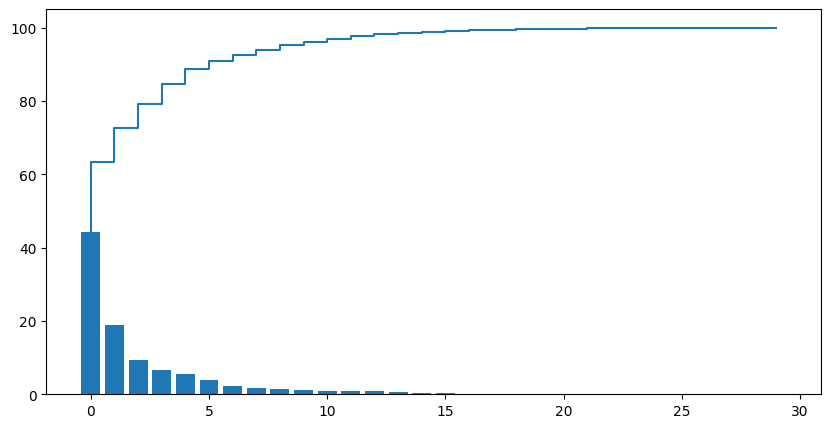

In [25]:
# screeplot
plt.figure(figsize=(10,5))
plt.bar(range(len(var_exp)),var_exp,label='Individuale explained variance')
plt.step(range(len(cum_var_exp)),cum_var_exp,label='cumulative explained varaince')
plt.show()


- We have almost contain the 95% of the data in below 15 PCA components.

In [26]:
# Applying PCA
from sklearn.decomposition import PCA

In [28]:
pca = PCA(0.95)
x_pca = pca.fit_transform(x_scaled)

In [29]:
df_1 = pd.DataFrame(x_pca)

In [30]:
df_1.shape

(569, 10)

- This tells PCA to retain enough components such that 95% variance is captured.
- We have converted all the old features into 10 new features.

In [31]:
pca.explained_variance_ratio_

array([0.44272026, 0.18971182, 0.09393163, 0.06602135, 0.05495768,
       0.04024522, 0.02250734, 0.01588724, 0.01389649, 0.01168978])

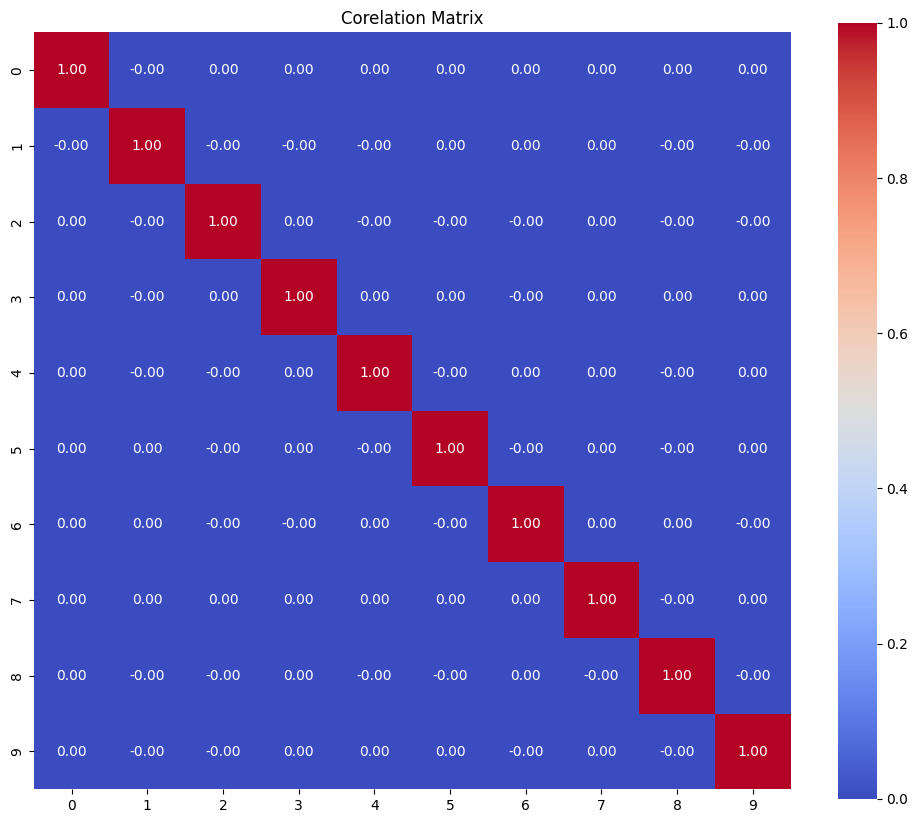

In [32]:
plt.figure(figsize=(10,10))
correlation_matrix = df_1.iloc[:,:30].corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f",cmap='coolwarm',
            square=True,cbar_kws = {'shrink':0.8})
plt.tight_layout()
plt.title("Corelation Matrix")
plt.show()

### STEP 7. Divide the dataset into features (x) and the target variable (y) for training the model.

In [33]:
from sklearn.model_selection import train_test_split

In [34]:
x_train,x_test,y_train,y_test = train_test_split(x_pca,y,test_size=0.2,random_state=42)

### STEP 7.Model Selection & Training: Choose algorithms based on problem type.


In [35]:
from sklearn.ensemble import RandomForestClassifier

In [36]:
# Train the model.
rf  = RandomForestClassifier(class_weight='balanced',n_estimators=50,random_state=23)
rf.fit(x_train,y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=50,
                       random_state=23)

In [37]:
# Predicting the values with test data.
y_pred = rf.predict(x_test)

In [38]:
new_df = pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
new_df.head(10)

,Actual,Predicted
0,1,1
1,0,0
2,0,0
3,1,1
4,1,1
5,0,0
6,0,0
7,0,0
8,1,0
9,1,1


### STEP 8: Model Evaluation  
- Assessing the performance of the model based on various parameters.


In [39]:
from sklearn.metrics import *

In [40]:
accuracy_score(y_test,y_pred)

0.956140350877193

In [41]:
confusion_matrix(y_pred,y_test)

array([[41,  3],
       [ 2, 68]])

- After building the ML model using the PCA data, we evaluated it and achieved " 95 % accuracy ".


In [42]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.93      0.95      0.94        43
           1       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [43]:
recall_score(y_pred,y_test)

0.9714285714285714

In [44]:
# Training the model with various n_estimators values.
n_estimators=[50,100,150,200,250,300,350,400,450,500,550,600,650]
for i in n_estimators:
    temp_model=RandomForestClassifier(n_estimators=i,random_state=23)
    temp_model.fit(x_train,y_train)
    y_pred=temp_model.predict(x_test)
    acc=accuracy_score(y_test,y_pred)
    print(f'The accuracy for n_estimator {i} is {acc}')

The accuracy for n_estimator 50 is 0.956140350877193
The accuracy for n_estimator 100 is 0.9473684210526315
The accuracy for n_estimator 150 is 0.9473684210526315
The accuracy for n_estimator 200 is 0.9473684210526315
The accuracy for n_estimator 250 is 0.9473684210526315
The accuracy for n_estimator 300 is 0.9473684210526315
The accuracy for n_estimator 350 is 0.9473684210526315
The accuracy for n_estimator 400 is 0.9473684210526315
The accuracy for n_estimator 450 is 0.9473684210526315
The accuracy for n_estimator 500 is 0.9473684210526315
The accuracy for n_estimator 550 is 0.9473684210526315
The accuracy for n_estimator 600 is 0.9473684210526315
The accuracy for n_estimator 650 is 0.9473684210526315
